Dieses Skript wird mit dem vollständigen MNIST-Datensatz trainiert, um das Rauschen aus den Bildern zu entfernen. 
Dazu werden zwei Ansätze verglichen und visualisiert: DNN und CNN.

In [1]:
import tensorflow as tf # getestet mit Version 2.17.0
print(tf.__version__)

from tensorflow.keras import layers, models
import numpy as np
import matplotlib as mpl # getestet mit Version 3.8.4
print(mpl.__version__)
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

2.10.0
3.6.2


In [2]:
# MNIST-Daten laden
(x_train, _), (x_test, _) = mnist.load_data()

# Daten normalisieren und Reshape
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test = np.reshape(x_test, (len(x_test), 28, 28, 1))
print(x_train.shape)
print(x_test.shape)

# Rauschen hinzufügen
noise_factor = 0.5
x_train_noisy = x_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape) 
x_test_noisy = x_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)

x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

(60000, 28, 28, 1)
(10000, 28, 28, 1)


## Teil I: Convolutional Neuronal Network

In [3]:
img_shape=(28, 28, 1)
input_img = layers.Input(shape=img_shape)

# Encoder
x = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(input_img)
x = layers.MaxPooling2D((2, 2), padding='same')(x)
x = layers.Conv2D(8, (3, 3), activation='relu', padding='same')(x)
encoded = layers.MaxPooling2D((2, 2), padding='same')(x)
print(encoded.shape)

# Decoder
x = layers.Conv2DTranspose(16, (3, 3), strides=2, activation='relu', padding='same')(encoded)
x = layers.Conv2DTranspose(8, (3, 3), strides=2, activation='relu', padding='same')(x)
decoded = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

# This model maps an input to its encoded representation
encoder = models.Model(input_img, encoded)

# Autoencoder
autoencoder = models.Model(input_img, decoded)
    
# Decoder
# Retrieve the last layer of the autoencoder model
decoder_layer = autoencoder.layers[-1]
# Create the decoder model
decoder = models.Model(encoded, decoder_layer(encoded))
    
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

(None, 7, 7, 8)


In [4]:
# Autoencoder trainieren
autoencoder.fit(x_train_noisy, x_train, epochs=20, batch_size=256, shuffle=True, validation_data=(x_test_noisy, x_test))
# Laufzeit ca. 8 Minuten (ohne GPU)

Epoch 1/20
235/235 [==============================] - 28s 116ms/step - loss: 0.3388 - val_loss: 0.1757
Epoch 2/20
235/235 [==============================] - 27s 116ms/step - loss: 0.1459 - val_loss: 0.1346
Epoch 3/20
235/235 [==============================] - 27s 116ms/step - loss: 0.1322 - val_loss: 0.1288
Epoch 4/20
235/235 [==============================] - 28s 117ms/step - loss: 0.1278 - val_loss: 0.1256
Epoch 5/20
235/235 [==============================] - 27s 117ms/step - loss: 0.1249 - val_loss: 0.1229
Epoch 6/20
235/235 [==============================] - 28s 117ms/step - loss: 0.1229 - val_loss: 0.1213
Epoch 7/20
235/235 [==============================] - 27s 115ms/step - loss: 0.1213 - val_loss: 0.1198
Epoch 8/20
235/235 [==============================] - 27s 115ms/step - loss: 0.1200 - val_loss: 0.1185
Epoch 9/20
235/235 [==============================] - 27s 115ms/step - loss: 0.1189 - val_loss: 0.1178
Epoch 10/20
235/235 [==============================] - 27s 115ms/step - l

313/313 [==============================] - 2s 7ms/step


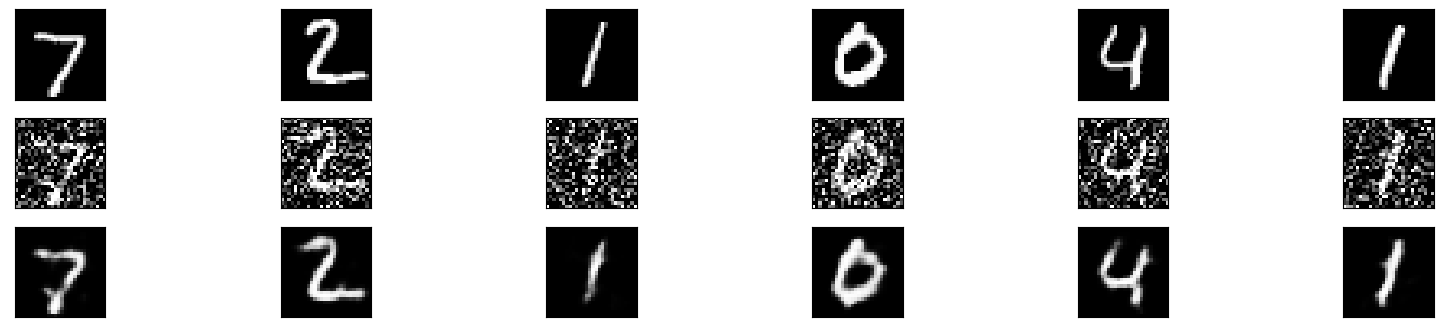

In [5]:
decoded_imgs = autoencoder.predict(x_test_noisy)

n = 6  # How many digits we will display
plt.figure(figsize=(20, 4))
for i in range(n):
    # Display original
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28),cmap='gray')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Display noisy
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(x_test_noisy[i].reshape(28, 28),cmap='gray')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    
    # Display reconstruction
    ax = plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(decoded_imgs[i].reshape(28, 28),cmap='gray')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

313/313 [==============================] - 1s 4ms/step


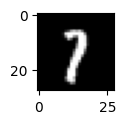

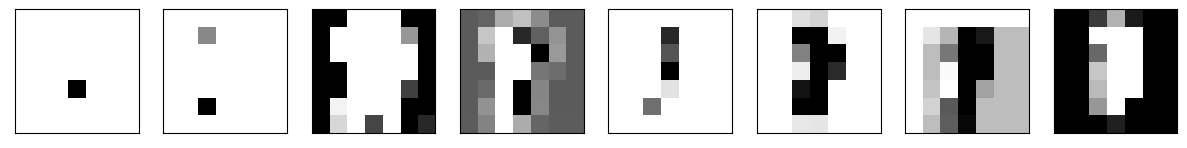

In [6]:
# Visualisierung vom lantenten Raum 

# Encodieren vom Test-Datensatz
encoded_imgs = encoder.predict(x_test)

image = 111 # Zufällige Zahl, um ein Bild aus dem Test-Datensatz auszusuchen
plt.figure(figsize=(20, 1))
plt.imshow(x_test[image],cmap='gray')
plt.show()

# Die Werte des ausgewählten encodierten Bildes werden auf den Bereich [0, 255] skaliert,
# indem die Werte des Bildes mit 255 multipliziert und dann mit np.clip begrenzt werden,
# um sicherzustellen, dass alle Werte im Bereich von 0 bis 255 liegen.
# Anschließend wird der Datentyp in uint8 konvertiert, um das Bild im Standard-Format für Bilder zu speichern.
enc_i = np.clip(encoded_imgs[image] * 255, 0, 255).astype(np.uint8)

# Anzahl der zu visualisierenden Bilder = Anzahl CNN Filters im letzten Encoder-Layer (latenter Raum)
num_images = encoded_imgs[image].shape[-1]

# Erstellen Sie eine Figur mit Unterplots
fig, axes = plt.subplots(nrows=1, ncols=8, figsize=(15, 4))

for i in range(num_images):
    img = enc_i[:, :, i]    # Wählen Sie das aktuelle Image aus
    ax = axes[i]
    ax.imshow(img,cmap='gray')  # Zeige das Image im Unterplot
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

plt.show()

## Teil II: Deep Neuronal Network

In [10]:
img_shape=(28, 28, 1)
input_img = layers.Input(shape=img_shape)

# Encoder
xII = layers.Flatten()(input_img)  # Flatten the input image
xII = layers.Dense(64, activation='relu')(xII)
encodedII = layers.Dense(16, activation='relu')(xII)

# Decoder
xII = layers.Dense(64, activation='relu')(encodedII)
xII = layers.Dense(784, activation='relu')(xII)
decodedII = layers.Reshape(img_shape)(xII)

# Dieses Modell bildet eine Eingabe auf ihre kodierte Darstellung ab
encoderII = models.Model(input_img, encodedII)

# Autoencoder
autoencoderII = models.Model(input_img, decodedII)
    
autoencoderII.compile(optimizer='adam', loss='binary_crossentropy')

In [11]:
# Autoencoder trainieren
autoencoderII.fit(x_train_noisy, x_train, epochs=30, batch_size=256, shuffle=True, validation_data=(x_test_noisy, x_test))
# Laufzeit ca. 1 Minute (ohne GPU)

Epoch 1/30
235/235 [==============================] - 2s 8ms/step - loss: 0.4140 - val_loss: 0.3303
Epoch 2/30
235/235 [==============================] - 2s 8ms/step - loss: 0.3291 - val_loss: 0.3239
Epoch 3/30
235/235 [==============================] - 2s 8ms/step - loss: 0.3247 - val_loss: 0.3147
Epoch 4/30
235/235 [==============================] - 2s 8ms/step - loss: 0.3134 - val_loss: 0.3075
Epoch 5/30
235/235 [==============================] - 2s 8ms/step - loss: 0.3082 - val_loss: 0.3210
Epoch 6/30
235/235 [==============================] - 2s 8ms/step - loss: 0.3012 - val_loss: 0.2989
Epoch 7/30
235/235 [==============================] - 2s 8ms/step - loss: 0.2879 - val_loss: 0.2832
Epoch 8/30
235/235 [==============================] - 2s 8ms/step - loss: 0.2938 - val_loss: 0.2880
Epoch 9/30
235/235 [==============================] - 2s 8ms/step - loss: 0.2920 - val_loss: 0.2894
Epoch 10/30
235/235 [==============================] - 2s 7ms/step - loss: 0.2739 - val_loss: 0.2627

313/313 [==============================] - 1s 1ms/step


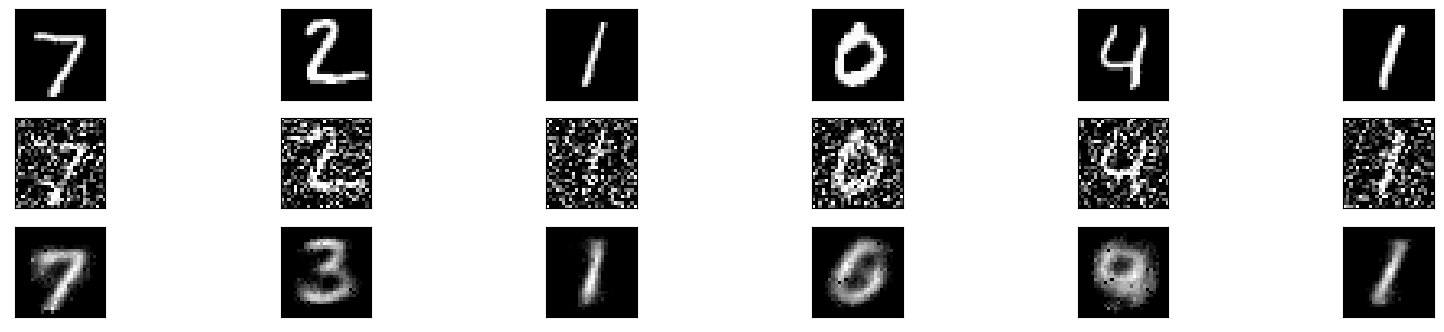

In [12]:
decoded_imgs = autoencoderII.predict(x_test_noisy)

n = 6  # Wie viele Bildr sollen dargestellt werden
plt.figure(figsize=(20, 4))
for i in range(n):
    # Display original
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28),cmap='gray')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Display verrauschtes Bild
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(x_test_noisy[i].reshape(28, 28),cmap='gray')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    
    # Display Rekonstruktion
    ax = plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(decoded_imgs[i].reshape(28, 28),cmap='gray')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()